# AeroVision LK — SAHI Inference

**Week 2 | Day 8–10**  
**Model:** YOLOv8s baseline weights + SAHI sliced inference  
**Dataset:** VisDrone2019-DET val split (548 images)

---

### Baseline results to beat (notebook 02)

| Metric | Value |
|---|---|
| mAP@0.5 | **44.08%** |
| mAP@0.5:0.95 | **26.09%** |
| bicycle AP@0.5 | 13.2% (biggest weak spot) |
| people AP@0.5 | 35.2% |
| three_wheeler AP@0.5 | 36.8% |

**Updated target: 55%+ mAP@0.5 (+11pp over baseline)**

### Why SAHI?
78.7% of VisDrone objects are < 50×50 px. YOLOv8 letterboxes every image to 640×640,
shrinking those objects further. SAHI tiles the full-resolution image into overlapping
512×512 slices, runs detection on each, and merges results — keeping small objects
large enough to detect.

---

In [25]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import datetime
import yaml
import time
import mlflow
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ── Project root ──────────────────────────────────────────────────────────────
def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / 'data' / 'VisDrone_Dataset').exists():
            return candidate
    raise RuntimeError('Cannot find project root. Run from 01_aerovision_lk/ or research/')

PROJECT_ROOT     = find_project_root()
DATASET_ROOT     = PROJECT_ROOT / 'data' / 'VisDrone_Dataset'
DATASET_YAML_ABS = DATASET_ROOT / 'visdrone_abs.yaml'
BASELINE_WEIGHTS = PROJECT_ROOT / 'weights' / 'yolov8s_baseline.pt'
FIGURES_DIR      = PROJECT_ROOT / 'reports' / 'figures'
ANALYSIS_DIR     = PROJECT_ROOT / 'analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

VAL_IMAGES_DIR = DATASET_ROOT / 'VisDrone2019-DET-val' / 'images'
VAL_LABELS_DIR = DATASET_ROOT / 'VisDrone2019-DET-val' / 'labels'

CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'three_wheeler', 'bus', 'motor']
NC = len(CLASS_NAMES)
WEAK_SPOTS = {'bicycle', 'people', 'three_wheeler'}

COLORS_RGB = [
    (255,  59,  59), (255, 149,   0), (255, 214,   0),
    ( 52, 199,  89), (  0, 190, 235), (  0, 122, 255),
    (175,  82, 222), (255,  45, 143), (162, 132,  94),
]
COLORS_BGR = [(b, g, r) for r, g, b in COLORS_RGB]

# ── Assert prerequisites ──────────────────────────────────────────────────────
assert BASELINE_WEIGHTS.exists(),  f'Missing: {BASELINE_WEIGHTS}  — run notebook 02 first'
assert DATASET_YAML_ABS.exists(),  f'Missing: {DATASET_YAML_ABS} — run notebook 02 first'

# ── Load baseline metrics ─────────────────────────────────────────────────────
baseline_csv = ANALYSIS_DIR / 'baseline_metrics.csv'
assert baseline_csv.exists(), f'Missing: {baseline_csv}'
baseline_row     = pd.read_csv(baseline_csv).iloc[-1]
BASELINE_MAP50   = float(baseline_row['mAP50'])
BASELINE_MAP5095 = float(baseline_row['mAP50_95'])

n_val = len(list(VAL_IMAGES_DIR.glob('*.jpg')))
print(f'Project root     : {PROJECT_ROOT}')
print(f'Baseline weights : {BASELINE_WEIGHTS.name}  ({BASELINE_WEIGHTS.stat().st_size/1024/1024:.1f} MB)')
print(f'Val images       : {n_val}')
print(f'Baseline mAP@0.5 : {BASELINE_MAP50*100:.2f}%')
print(f'Target mAP@0.5   : 55%+  (need +{(0.55-BASELINE_MAP50)*100:.1f}pp)')

Project root     : c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk
Baseline weights : yolov8s_baseline.pt  (21.5 MB)
Val images       : 548
Baseline mAP@0.5 : 44.08%
Target mAP@0.5   : 55%+  (need +10.9pp)


---
## 1. Load Models

In [26]:
# ── Raw YOLO (for baseline inference in visuals + recall comparison) ───────────
yolo_model = YOLO(BASELINE_WEIGHTS)
print(f'YOLO model loaded      : {BASELINE_WEIGHTS.name}')

# ── SAHI AutoDetectionModel ───────────────────────────────────────────────────
CONF_THRESHOLD = 0.25
SLICE_SIZE     = 512
OVERLAP_RATIO  = 0.2

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=str(BASELINE_WEIGHTS),
    confidence_threshold=CONF_THRESHOLD,
    device='cuda:0',
)
print(f'SAHI model loaded      : confidence_threshold={CONF_THRESHOLD}, device=cuda:0')
print(f'SAHI slice config      : {SLICE_SIZE}x{SLICE_SIZE}, overlap={OVERLAP_RATIO}')

YOLO model loaded      : yolov8s_baseline.pt
SAHI model loaded      : confidence_threshold=0.25, device=cuda:0
SAHI slice config      : 512x512, overlap=0.2


---
## 2. Shared Helpers

In [27]:
def load_label(label_path: Path):
    """Return (boxes_norm [N,4], class_ids [N]) from a YOLO label file."""
    rows, cids = [], []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            cids.append(int(parts[0]))
            rows.append([float(x) for x in parts[1:]])
    boxes = np.array(rows, dtype=np.float32) if rows else np.zeros((0, 4), dtype=np.float32)
    return boxes, cids


def yolo_to_xyxy(boxes_norm, img_w, img_h):
    """Convert YOLO normalised [cx,cy,w,h] -> pixel [x1,y1,x2,y2]."""
    if len(boxes_norm) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    cx, cy, bw, bh = boxes_norm[:,0], boxes_norm[:,1], boxes_norm[:,2], boxes_norm[:,3]
    x1 = (cx - bw/2) * img_w
    y1 = (cy - bh/2) * img_h
    x2 = (cx + bw/2) * img_w
    y2 = (cy + bh/2) * img_h
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)


def iou_matrix(gt_xyxy, pred_xyxy):
    """Vectorized IoU matrix [N_gt, N_pred]. No external dependencies."""
    if len(gt_xyxy) == 0 or len(pred_xyxy) == 0:
        return np.zeros((len(gt_xyxy), len(pred_xyxy)), dtype=np.float32)
    gt   = gt_xyxy[:, None, :]
    pred = pred_xyxy[None, :, :]
    ix1  = np.maximum(gt[...,0], pred[...,0])
    iy1  = np.maximum(gt[...,1], pred[...,1])
    ix2  = np.minimum(gt[...,2], pred[...,2])
    iy2  = np.minimum(gt[...,3], pred[...,3])
    inter = np.maximum(0.0, ix2-ix1) * np.maximum(0.0, iy2-iy1)
    area_gt   = (gt_xyxy[:,2]-gt_xyxy[:,0]) * (gt_xyxy[:,3]-gt_xyxy[:,1])
    area_pred = (pred_xyxy[:,2]-pred_xyxy[:,0]) * (pred_xyxy[:,3]-pred_xyxy[:,1])
    union = area_gt[:,None] + area_pred[None,:] - inter
    return inter / np.maximum(union, 1e-6)


def compute_ap(recalls, precisions):
    """101-point interpolated AP (COCO-style)."""
    r = np.concatenate(([0.0], recalls,    [1.0]))
    p = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(p)-2, -1, -1):
        p[i] = max(p[i], p[i+1])
    x  = np.linspace(0, 1, 101)
    ap = float(np.trapezoid(np.interp(x, r, p), x))
    return ap


def compute_map(all_preds, all_gts, iou_threshold=0.5):
    """
    Compute mAP across all classes.
    all_preds: list of dicts {class_id, conf, img_id, x1,y1,x2,y2}
    all_gts:   list of dicts {class_id, img_id, gt_idx, x1,y1,x2,y2}
    Returns: (mAP float, per_class_ap dict {cid: float})
    """
    per_class_ap = {}
    for cid in range(NC):
        preds = sorted([p for p in all_preds if p['class_id'] == cid], key=lambda x: -x['conf'])
        gts   = [g for g in all_gts if g['class_id'] == cid]
        if not gts:
            continue
        matched = set()
        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))
        for i, pred in enumerate(preds):
            img_gts = [g for g in gts if g['img_id'] == pred['img_id']]
            if not img_gts:
                fp[i] = 1; continue
            pb  = np.array([[pred['x1'], pred['y1'], pred['x2'], pred['y2']]], dtype=np.float32)
            gb  = np.array([[g['x1'],g['y1'],g['x2'],g['y2']] for g in img_gts], dtype=np.float32)
            ious = iou_matrix(gb, pb)[:,0]
            best = int(np.argmax(ious))
            key  = (pred['img_id'], img_gts[best]['gt_idx'])
            if ious[best] >= iou_threshold and key not in matched:
                tp[i] = 1; matched.add(key)
            else:
                fp[i] = 1
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        rec  = cum_tp / (len(gts) + 1e-6)
        prec = cum_tp / (cum_tp + cum_fp + 1e-6)
        per_class_ap[cid] = compute_ap(rec, prec)
    mAP = float(np.mean(list(per_class_ap.values()))) if per_class_ap else 0.0
    return mAP, per_class_ap


def get_most_crowded(labels_dir: Path, n=5):
    files  = list(labels_dir.glob('*.txt'))
    counts = [(f, sum(1 for l in f.read_text().splitlines() if l.strip())) for f in files]
    return sorted(counts, key=lambda x: x[1], reverse=True)[:n]


def sahi_to_boxes(sahi_result):
    """Extract (boxes_xyxy [N,4], class_ids [N], confs [N]) from SAHI result."""
    boxes, cids, confs = [], [], []
    for obj in sahi_result.object_prediction_list:
        b = obj.bbox
        boxes.append([b.minx, b.miny, b.maxx, b.maxy])
        cids.append(int(obj.category.id))
        confs.append(float(obj.score.value))
    boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0,4), dtype=np.float32)
    return boxes, cids, confs


print('Helpers defined.')

Helpers defined.


---
## 3. Visual Comparison — 2 Most Crowded Val Images

Left: baseline YOLOv8s @ 640px  |  Right: SAHI 512×512 slices, overlap 0.2  
This is the key qualitative proof — more boxes on the right = more small objects detected.

Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\reports\figures\sahi_visual_comparison.png


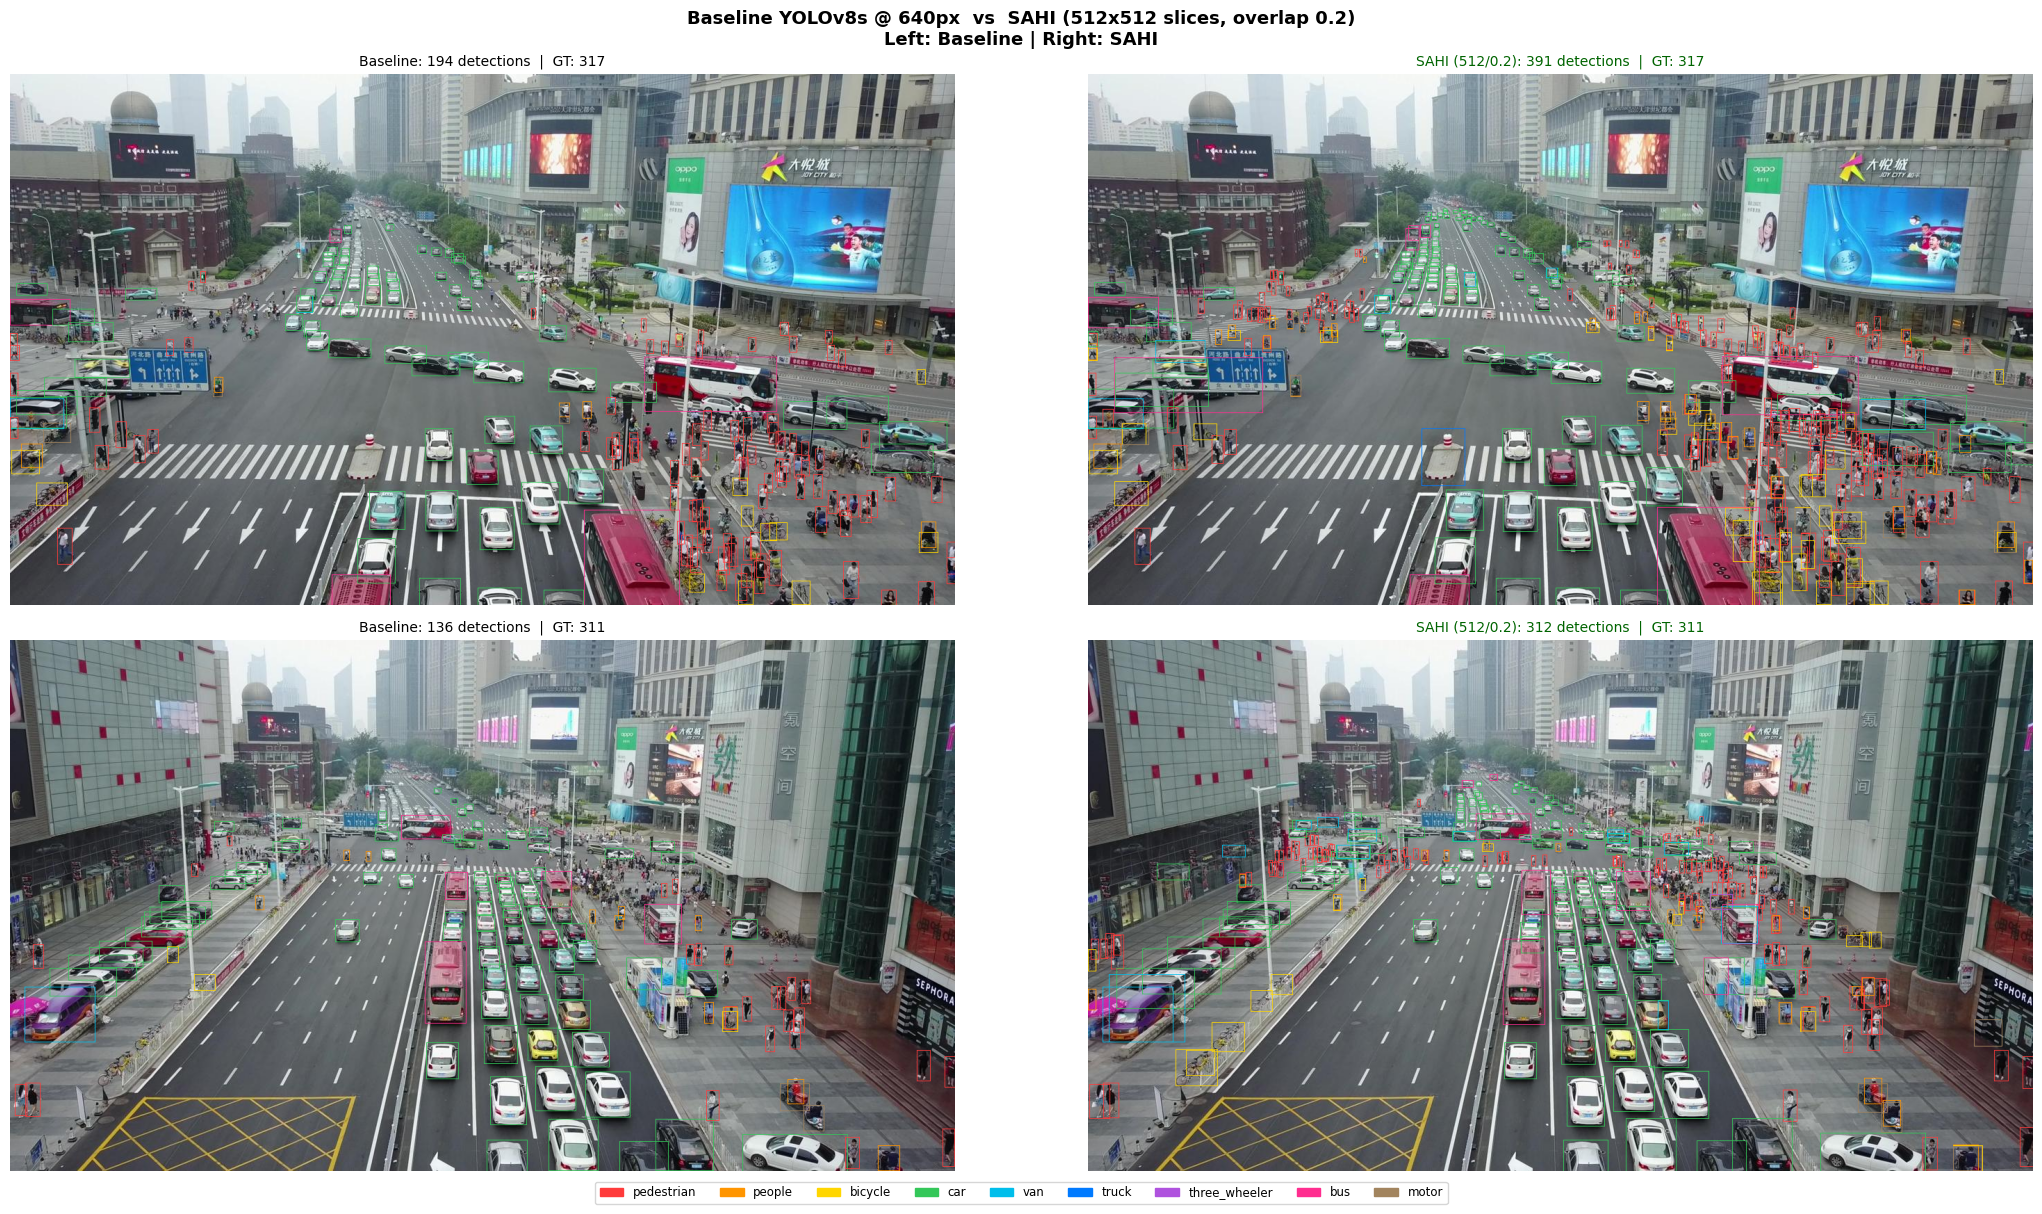

In [28]:
crowded = get_most_crowded(VAL_LABELS_DIR, n=2)

fig, axes = plt.subplots(2, 2, figsize=(22, 12))
fig.suptitle(
    'Baseline YOLOv8s @ 640px  vs  SAHI (512x512 slices, overlap 0.2)\n'
    'Left: Baseline | Right: SAHI',
    fontsize=13, fontweight='bold'
)

for row_idx, (label_path, ann_count) in enumerate(crowded):
    img_path = VAL_IMAGES_DIR / (label_path.stem + '.jpg')
    img_bgr  = cv2.imread(str(img_path))
    h, w     = img_bgr.shape[:2]

    # ── Baseline ──────────────────────────────────────────────────────────────
    base_res   = yolo_model.predict(source=str(img_path), imgsz=640,
                                    conf=CONF_THRESHOLD, iou=0.45, verbose=False)[0]
    base_boxes = base_res.boxes.xyxy.cpu().numpy().astype(int) if len(base_res.boxes) else np.zeros((0,4), dtype=int)
    base_cids  = base_res.boxes.cls.cpu().numpy().astype(int)  if len(base_res.boxes) else []
    base_canvas = img_bgr.copy()
    for (x1,y1,x2,y2), cid in zip(base_boxes, base_cids):
        cv2.rectangle(base_canvas, (x1,y1), (x2,y2), COLORS_BGR[cid % NC], 1)

    # ── SAHI ──────────────────────────────────────────────────────────────────
    sahi_res   = get_sliced_prediction(
        str(img_path), detection_model,
        slice_height=SLICE_SIZE, slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP_RATIO, overlap_width_ratio=OVERLAP_RATIO,
        verbose=False,
    )
    sahi_boxes, sahi_cids, _ = sahi_to_boxes(sahi_res)
    sahi_canvas = img_bgr.copy()
    for (x1,y1,x2,y2), cid in zip(sahi_boxes.astype(int), sahi_cids):
        cv2.rectangle(sahi_canvas, (x1,y1), (x2,y2), COLORS_BGR[cid % NC], 1)

    # ── Plot ──────────────────────────────────────────────────────────────────
    ax_b, ax_s = axes[row_idx, 0], axes[row_idx, 1]
    ax_b.imshow(cv2.cvtColor(base_canvas, cv2.COLOR_BGR2RGB))
    ax_b.set_title(f'Baseline: {len(base_boxes)} detections  |  GT: {ann_count}', fontsize=10)
    ax_b.axis('off')
    ax_s.imshow(cv2.cvtColor(sahi_canvas, cv2.COLOR_BGR2RGB))
    ax_s.set_title(
        f'SAHI (512/0.2): {len(sahi_boxes)} detections  |  GT: {ann_count}',
        fontsize=10, color='darkgreen' if len(sahi_boxes) > len(base_boxes) else 'black'
    )
    ax_s.axis('off')

legend_patches = [mpatches.Patch(color=[c/255 for c in col], label=name)
                  for name, col in zip(CLASS_NAMES, COLORS_RGB)]
fig.legend(handles=legend_patches, loc='lower center', ncol=9,
           fontsize=8.5, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
out_path = FIGURES_DIR / 'sahi_visual_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

---
## 4. Full Val Set Evaluation — SAHI

Run SAHI on all 548 val images and accumulate predictions for mAP computation.
Expected runtime: ~20 min on RTX 3050.

In [29]:
# ── Ensure correct confidence threshold ────────────────────────────────────────
detection_model.confidence_threshold = 0.25
CONF_THRESHOLD = 0.25

val_images = sorted(VAL_IMAGES_DIR.glob('*.jpg'))
n_images   = len(val_images)
t_start    = datetime.datetime.now()

print('=' * 58)
print('  SAHI Full Val Evaluation')
print('=' * 58)
print(f'  Val image count  : {n_images}')
print(f'  Slice config     : {SLICE_SIZE}x{SLICE_SIZE}, overlap {OVERLAP_RATIO}')
print(f'  Conf threshold   : {CONF_THRESHOLD}')
print(f'  Estimated runtime: ~20 min on RTX 3050')
print(f'  Start time       : {t_start.strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 58)

all_preds = []   # {class_id, conf, img_id, x1,y1,x2,y2}
all_gts   = []   # {class_id, img_id, gt_idx, x1,y1,x2,y2}

for img_idx, img_path in enumerate(val_images):
    label_path = VAL_LABELS_DIR / (img_path.stem + '.txt')
    if not label_path.exists():
        continue

    img        = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    img_id     = img_path.stem

    # Ground truth
    gt_norm, gt_cids = load_label(label_path)
    gt_xyxy          = yolo_to_xyxy(gt_norm, img_w, img_h)
    for gt_idx, (box, cid) in enumerate(zip(gt_xyxy, gt_cids)):
        all_gts.append({'class_id': cid, 'img_id': img_id, 'gt_idx': gt_idx,
                        'x1': float(box[0]), 'y1': float(box[1]),
                        'x2': float(box[2]), 'y2': float(box[3])})

    # SAHI inference
    sahi_res = get_sliced_prediction(
        str(img_path), detection_model,
        slice_height=SLICE_SIZE, slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP_RATIO, overlap_width_ratio=OVERLAP_RATIO,
        verbose=False,
    )
    pred_boxes, pred_cids, pred_confs = sahi_to_boxes(sahi_res)
    for box, cid, conf in zip(pred_boxes, pred_cids, pred_confs):
        all_preds.append({'class_id': int(cid), 'conf': float(conf), 'img_id': img_id,
                          'x1': float(box[0]), 'y1': float(box[1]),
                          'x2': float(box[2]), 'y2': float(box[3])})

    if (img_idx + 1) % 50 == 0 or (img_idx + 1) == n_images:
        elapsed = (datetime.datetime.now() - t_start).total_seconds()
        rate    = (img_idx + 1) / max(elapsed, 1e-6)
        eta     = (n_images - img_idx - 1) / max(rate, 1e-6)
        print(f'  [{img_idx+1:>3}/{n_images}]  elapsed {elapsed/60:.1f} min  '
              f'ETA {eta/60:.1f} min  ({rate:.1f} img/s)')

t_end   = datetime.datetime.now()
elapsed = (t_end - t_start).total_seconds()
print()
print(f'  End time    : {t_end.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Actual time : {elapsed/60:.1f} min ({elapsed:.0f} s)')
print(f'  Total preds : {len(all_preds):,}')
print(f'  Total GTs   : {len(all_gts):,}')

  SAHI Full Val Evaluation
  Val image count  : 548
  Slice config     : 512x512, overlap 0.2
  Conf threshold   : 0.25
  Estimated runtime: ~20 min on RTX 3050
  Start time       : 2026-03-24 03:56:39
  [ 50/548]  elapsed 0.2 min  ETA 2.5 min  (3.4 img/s)
  [100/548]  elapsed 0.5 min  ETA 2.0 min  (3.7 img/s)
  [150/548]  elapsed 0.7 min  ETA 1.9 min  (3.6 img/s)
  [200/548]  elapsed 0.9 min  ETA 1.6 min  (3.7 img/s)
  [250/548]  elapsed 1.1 min  ETA 1.4 min  (3.7 img/s)
  [300/548]  elapsed 1.4 min  ETA 1.1 min  (3.6 img/s)
  [350/548]  elapsed 1.6 min  ETA 0.9 min  (3.6 img/s)
  [400/548]  elapsed 1.9 min  ETA 0.7 min  (3.5 img/s)
  [450/548]  elapsed 2.1 min  ETA 0.5 min  (3.5 img/s)
  [500/548]  elapsed 2.4 min  ETA 0.2 min  (3.5 img/s)
  [548/548]  elapsed 2.6 min  ETA 0.0 min  (3.5 img/s)

  End time    : 2026-03-24 03:59:14
  Actual time : 2.6 min (155 s)
  Total preds : 43,931
  Total GTs   : 38,759


---
## 5. Compute mAP@0.5 and mAP@0.5:0.95

In [30]:
print('Computing mAP@0.5 ...')
sahi_map50, sahi_ap50_per_class = compute_map(all_preds, all_gts, iou_threshold=0.5)
print(f'  mAP@0.5 = {sahi_map50*100:.2f}%')

print('Computing mAP@0.5:0.95 (10 thresholds) ...')
iou_thresholds = np.arange(0.5, 1.0, 0.05)
map5095_list   = []
ap5095_accum   = {cid: [] for cid in range(NC)}

for thresh in iou_thresholds:
    m, per_cls = compute_map(all_preds, all_gts, iou_threshold=round(float(thresh), 2))
    map5095_list.append(m)
    for cid, ap in per_cls.items():
        ap5095_accum[cid].append(ap)
    print(f'  IoU={thresh:.2f} -> mAP={m*100:.2f}%')

sahi_map5095         = float(np.mean(map5095_list))
sahi_ap5095_per_class = {cid: float(np.mean(v)) for cid, v in ap5095_accum.items() if v}

print()
print(f'  mAP@0.5      = {sahi_map50*100:.2f}%')
print(f'  mAP@0.5:0.95 = {sahi_map5095*100:.2f}%')

Computing mAP@0.5 ...
  mAP@0.5 = 54.33%
Computing mAP@0.5:0.95 (10 thresholds) ...
  IoU=0.50 -> mAP=54.33%
  IoU=0.55 -> mAP=51.76%
  IoU=0.60 -> mAP=48.64%
  IoU=0.65 -> mAP=44.46%
  IoU=0.70 -> mAP=39.70%
  IoU=0.75 -> mAP=33.42%
  IoU=0.80 -> mAP=26.00%
  IoU=0.85 -> mAP=17.45%
  IoU=0.90 -> mAP=8.23%
  IoU=0.95 -> mAP=1.50%

  mAP@0.5      = 54.33%
  mAP@0.5:0.95 = 32.55%


---
## 6. Results Comparison Table

In [31]:
# ── Build per-class comparison ────────────────────────────────────────────────
baseline_ap50 = {name: float(baseline_row[f'AP50_{name}'])
                 for name in CLASS_NAMES if f'AP50_{name}' in baseline_row.index}

per_class_rows = []
for cid, name in enumerate(CLASS_NAMES):
    b_ap  = baseline_ap50.get(name, 0.0)
    s_ap  = sahi_ap50_per_class.get(cid, 0.0)
    s_ap5095 = sahi_ap5095_per_class.get(cid, 0.0)
    per_class_rows.append({
        'class_id':    cid,
        'class_name':  name,
        'baseline_AP50': round(b_ap,     4),
        'sahi_AP50':     round(s_ap,     4),
        'delta_AP50':    round(s_ap-b_ap, 4),
        'sahi_AP5095':   round(s_ap5095,  4),
    })

per_class_df = (pd.DataFrame(per_class_rows)
                  .sort_values('delta_AP50', ascending=False)
                  .reset_index(drop=True))

delta_map50   = sahi_map50   - BASELINE_MAP50
delta_map5095 = sahi_map5095 - BASELINE_MAP5095

# ── Print table ───────────────────────────────────────────────────────────────
W = 68
print('=' * W)
print('  Results Comparison — YOLOv8s Baseline vs SAHI (512/0.2)')
print('=' * W)
print(f'  {"Metric":<22} {"Baseline":>10} {"SAHI":>10} {"Delta":>10}')
print('  ' + '-' * (W-2))
print(f'  {"mAP@0.5":<22} {BASELINE_MAP50*100:>9.2f}% {sahi_map50*100:>9.2f}% {delta_map50*100:>+9.2f}pp')
print(f'  {"mAP@0.5:0.95":<22} {BASELINE_MAP5095*100:>9.2f}% {sahi_map5095*100:>9.2f}% {delta_map5095*100:>+9.2f}pp')
print()
print(f'  {"Class":<22} {"Baseline":>10} {"SAHI":>10} {"Delta":>10}')
print('  ' + '-' * (W-2))
for _, row in per_class_df.iterrows():
    tag = '  <-- weak spot' if row['class_name'] in WEAK_SPOTS else ''
    print(f'  {row["class_name"]:<22} {row["baseline_AP50"]*100:>9.2f}% '
          f'{row["sahi_AP50"]*100:>9.2f}% {row["delta_AP50"]*100:>+9.2f}pp{tag}')
print('=' * W)
target_met = sahi_map50 >= 0.55
print(f'\n  Target 55%+ mAP@0.5: {"MET" if target_met else "NOT MET"}  ({sahi_map50*100:.2f}%)')

  Results Comparison — YOLOv8s Baseline vs SAHI (512/0.2)
  Metric                   Baseline       SAHI      Delta
  ------------------------------------------------------------------
  mAP@0.5                    44.08%     54.33%    +10.25pp
  mAP@0.5:0.95               26.09%     32.55%     +6.46pp

  Class                    Baseline       SAHI      Delta
  ------------------------------------------------------------------
  pedestrian                 44.47%     61.65%    +17.18pp
  people                     35.24%     48.46%    +13.22pp  <-- weak spot
  motor                      45.19%     57.67%    +12.48pp
  three_wheeler              36.77%     47.50%    +10.73pp  <-- weak spot
  bicycle                    13.18%     23.51%    +10.33pp  <-- weak spot
  bus                        59.47%     69.49%    +10.02pp
  van                        44.52%     52.93%     +8.41pp
  truck                      37.55%     42.60%     +5.05pp
  car                        80.34%     85.11%     +

---
## 7. Save Metrics & Log to MLflow

In [32]:
# ── Build CSV row ─────────────────────────────────────────────────────────────
sahi_row = {
    'model':         'yolov8s',
    'imgsz':         640,
    'epochs':        50,
    'batch':         4,
    'sahi':          True,
    'slice_size':    SLICE_SIZE,
    'overlap_ratio': OVERLAP_RATIO,
    'mAP50':         round(sahi_map50,   4),
    'mAP50_95':      round(sahi_map5095, 4),
    'precision':     None,
    'recall':        None,
    'weights':       str(BASELINE_WEIGHTS),
    'timestamp':     datetime.datetime.now().isoformat(timespec='seconds'),
}
for _, row in per_class_df.iterrows():
    sahi_row[f'AP50_{row["class_name"]}']   = row['sahi_AP50']
    sahi_row[f'AP5095_{row["class_name"]}'] = row['sahi_AP5095']

sahi_csv_path = ANALYSIS_DIR / 'sahi_metrics.csv'
new_df = pd.DataFrame([sahi_row])
if sahi_csv_path.exists():
    combined = pd.concat([pd.read_csv(sahi_csv_path), new_df], ignore_index=True)
else:
    combined = new_df
combined.to_csv(sahi_csv_path, index=False)
print(f'Saved -> {sahi_csv_path}')

# ── MLflow ────────────────────────────────────────────────────────────────────
mlflow.set_tracking_uri((PROJECT_ROOT / 'mlruns').as_uri())
mlflow.set_experiment('aerovision-lk')

with mlflow.start_run(run_name='yolov8s-sahi-512-02') as run:
    mlflow.log_params({
        'model':          'yolov8s',
        'sahi':           True,
        'slice_size':     SLICE_SIZE,
        'overlap_ratio':  OVERLAP_RATIO,
        'conf_threshold': CONF_THRESHOLD,
        'dataset':        'VisDrone2019-DET-9class',
    })
    mlflow.log_metric('val/mAP50',    sahi_map50)
    mlflow.log_metric('val/mAP50-95', sahi_map5095)
    mlflow.log_metric('delta_mAP50',  delta_map50)
    for cid, name in enumerate(CLASS_NAMES):
        if cid in sahi_ap50_per_class:
            mlflow.log_metric(f'AP50_{name}', sahi_ap50_per_class[cid])
    mlflow.log_artifact(str(sahi_csv_path), artifact_path='metrics')
    SAHI_RUN_ID = run.info.run_id

print(f'MLflow run : {SAHI_RUN_ID}')

Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\analysis\sahi_metrics.csv
MLflow run : d8e0a5138fe240e68eec529e01f49908


---
## 8. Per-class Comparison Bar Chart

Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\reports\figures\sahi_per_class_comparison.png


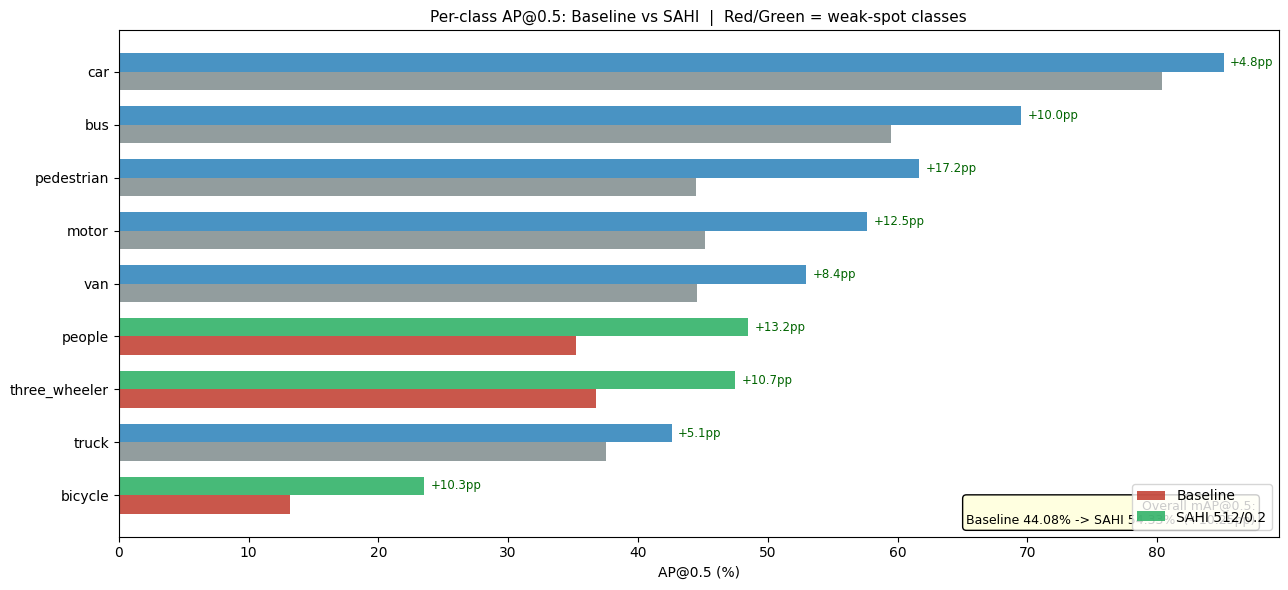

In [33]:
df_plot = per_class_df.sort_values('sahi_AP50', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))
y  = np.arange(len(df_plot))
bw = 0.35

base_colors = ['#c0392b' if n in WEAK_SPOTS else '#7f8c8d' for n in df_plot['class_name']]
sahi_colors = ['#27ae60' if n in WEAK_SPOTS else '#2980b9' for n in df_plot['class_name']]

ax.barh(y - bw/2, df_plot['baseline_AP50']*100, bw, color=base_colors, alpha=0.85, label='Baseline')
ax.barh(y + bw/2, df_plot['sahi_AP50']*100,     bw, color=sahi_colors, alpha=0.85, label='SAHI 512/0.2')

for i, (_, row) in enumerate(df_plot.iterrows()):
    delta = row['delta_AP50'] * 100
    ax.text(row['sahi_AP50']*100 + 0.5, y[i]+bw/2, f'{delta:+.1f}pp',
            va='center', fontsize=8.5,
            color='darkgreen' if delta > 0 else 'darkred')

ax.set_yticks(y)
ax.set_yticklabels(df_plot['class_name'])
ax.set_xlabel('AP@0.5 (%)')
ax.set_title('Per-class AP@0.5: Baseline vs SAHI  |  Red/Green = weak-spot classes', fontsize=11)
ax.legend(loc='lower right')
ax.text(0.98, 0.02,
        f'Overall mAP@0.5:\nBaseline {BASELINE_MAP50*100:.2f}% -> SAHI {sahi_map50*100:.2f}%'
        f'  ({delta_map50*100:+.2f}pp)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.tight_layout()
out_path = FIGURES_DIR / 'sahi_per_class_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

---
## 9. Small Object Recall by Size Bucket

Split all GT boxes into pixel-size buckets and measure recall for baseline vs SAHI.  
This directly quantifies SAHI's advantage on the small-object problem.

Running baseline inference on val set (~2 min)...
  100/548
  200/548
  300/548
  400/548
  500/548

  Bucket             N   Base Recall   SAHI Recall     Delta
  ----------------------------------------------------------
  <32px         26,586         43.3%         66.7%    +23.5pp
  32-64px        8,995         81.9%         88.1%     +6.2pp
  64-128px       2,849         95.0%         95.7%     +0.7pp
  >128px           329         94.8%         94.5%     -0.3pp
Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\reports\figures\sahi_small_object_recall.png


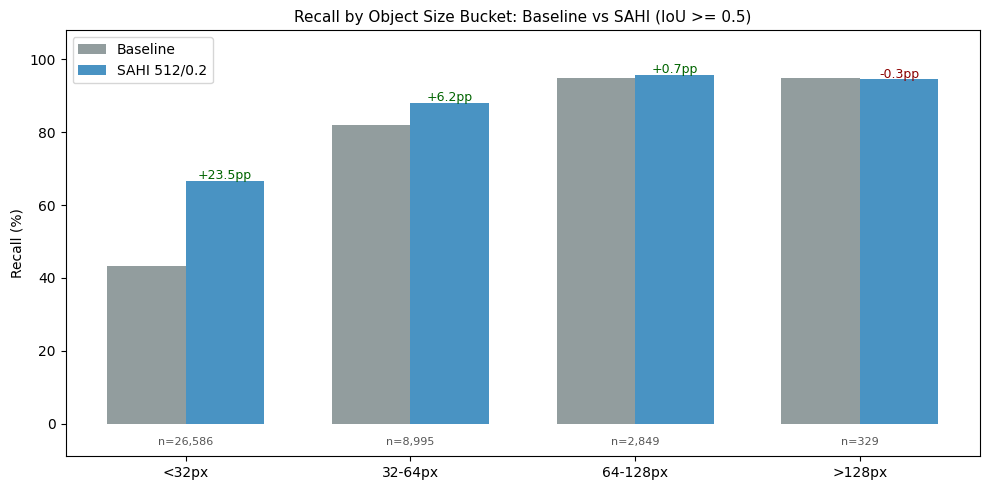

In [34]:
SIZE_BUCKETS = [('<32px', 0, 32), ('32-64px', 32, 64), ('64-128px', 64, 128), ('>128px', 128, 9999)]
IOU_THRESH   = 0.5

# ── Baseline predictions per image ───────────────────────────────────────────
print('Running baseline inference on val set (~2 min)...')
base_preds_by_img = {}
for i, img_path in enumerate(val_images):
    res = yolo_model.predict(source=str(img_path), imgsz=640,
                             conf=CONF_THRESHOLD, iou=0.45, verbose=False)[0]
    base_preds_by_img[img_path.stem] = (
        res.boxes.xyxy.cpu().numpy() if len(res.boxes) else np.zeros((0,4))
    )
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(val_images)}')

# ── SAHI predictions per image (already in all_preds) ────────────────────────
sahi_preds_by_img = {}
for p in all_preds:
    sahi_preds_by_img.setdefault(p['img_id'], []).append(
        [p['x1'], p['y1'], p['x2'], p['y2']])
sahi_preds_by_img = {
    k: np.array(v, dtype=np.float32) if v else np.zeros((0,4))
    for k, v in sahi_preds_by_img.items()
}

# ── Compute recall per GT per bucket ─────────────────────────────────────────
bucket_records = []
for lf in VAL_LABELS_DIR.glob('*.txt'):
    img_path = VAL_IMAGES_DIR / (lf.stem + '.jpg')
    if not img_path.exists(): continue
    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    gt_norm, _ = load_label(lf)
    gt_xyxy    = yolo_to_xyxy(gt_norm, img_w, img_h)
    if len(gt_xyxy) == 0: continue

    base_b = base_preds_by_img.get(lf.stem, np.zeros((0,4)))
    sahi_b = sahi_preds_by_img.get(lf.stem, np.zeros((0,4)))
    base_iou_max = iou_matrix(gt_xyxy, base_b).max(axis=1) if len(base_b) else np.zeros(len(gt_xyxy))
    sahi_iou_max = iou_matrix(gt_xyxy, sahi_b).max(axis=1) if len(sahi_b) else np.zeros(len(gt_xyxy))
    px_sides = np.sqrt((gt_xyxy[:,2]-gt_xyxy[:,0]) * (gt_xyxy[:,3]-gt_xyxy[:,1]))

    for j in range(len(gt_xyxy)):
        bucket_records.append({
            'px_side':  float(px_sides[j]),
            'base_hit': int(base_iou_max[j] >= IOU_THRESH),
            'sahi_hit': int(sahi_iou_max[j] >= IOU_THRESH),
        })

bdf = pd.DataFrame(bucket_records)

# ── Aggregate & print ─────────────────────────────────────────────────────────
print()
print(f'  {"Bucket":<12} {"N":>7}  {"Base Recall":>12}  {"SAHI Recall":>12}  {"Delta":>8}')
print('  ' + '-' * 58)
bucket_names, base_recs, sahi_recs, counts = [], [], [], []
for name, lo, hi in SIZE_BUCKETS:
    sub = bdf[(bdf['px_side'] >= lo) & (bdf['px_side'] < hi)]
    if len(sub) == 0: continue
    br = sub['base_hit'].mean()
    sr = sub['sahi_hit'].mean()
    bucket_names.append(name); base_recs.append(br)
    sahi_recs.append(sr);      counts.append(len(sub))
    print(f'  {name:<12} {len(sub):>7,}  {br*100:>11.1f}%  {sr*100:>11.1f}%  {(sr-br)*100:>+7.1f}pp')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(bucket_names))
bw = 0.35
ax.bar(x - bw/2, [r*100 for r in base_recs], bw, label='Baseline', color='#7f8c8d', alpha=0.85)
ax.bar(x + bw/2, [r*100 for r in sahi_recs], bw, label='SAHI 512/0.2', color='#2980b9', alpha=0.85)
for i in range(len(bucket_names)):
    d = (sahi_recs[i] - base_recs[i]) * 100
    ax.text(x[i]+bw/2, sahi_recs[i]*100+0.5, f'{d:+.1f}pp',
            ha='center', fontsize=9, color='darkgreen' if d > 0 else 'darkred')
    ax.text(x[i], -6, f'n={counts[i]:,}', ha='center', fontsize=8, color='#555')
ax.set_xticks(x)
ax.set_xticklabels(bucket_names)
ax.set_ylabel('Recall (%)')
ax.set_ylim(-9, 108)
ax.set_title('Recall by Object Size Bucket: Baseline vs SAHI (IoU >= 0.5)', fontsize=11)
ax.legend()
plt.tight_layout()
out_path = FIGURES_DIR / 'sahi_small_object_recall.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

---
## 10. Summary

In [ ]:
print('=' * 58)
print('  SAHI Results — YOLOv8s + SAHI 512x512 / overlap 0.2')
print('=' * 58)
print(f'  mAP@0.5      : {sahi_map50*100:.2f}%  ({delta_map50*100:+.2f}pp vs baseline {BASELINE_MAP50*100:.2f}%)')
print(f'  mAP@0.5:0.95 : {sahi_map5095*100:.2f}%  ({delta_map5095*100:+.2f}pp vs baseline {BASELINE_MAP5095*100:.2f}%)')
print()
print('  Weak-spot improvement:')
for name in ['bicycle', 'people', 'three_wheeler']:
    row = per_class_df[per_class_df['class_name'] == name].iloc[0]
    print(f'    {name:<15} {row["baseline_AP50"]*100:.1f}% -> {row["sahi_AP50"]*100:.1f}%'
          f'  ({row["delta_AP50"]*100:+.1f}pp)')
print()
print('  Saved files:')
for f in [
    FIGURES_DIR / 'sahi_visual_comparison.png',
    FIGURES_DIR / 'sahi_per_class_comparison.png',
    FIGURES_DIR / 'sahi_small_object_recall.png',
    ANALYSIS_DIR / 'sahi_metrics.csv',
]:
    status = 'OK' if f.exists() else 'MISSING'
    print(f'    [{status}] {f.name}')
print()
print('  Next: research/04_sahi_experiments.ipynb')
print('  Grid search: slice [320,512,640] x overlap [0.1,0.2,0.3]')
print('=' * 58)

  SAHI Results — YOLOv8s + SAHI 512x512 / overlap 0.2
  mAP@0.5      : 54.33%  (+10.25pp vs baseline 44.08%)
  mAP@0.5:0.95 : 32.55%  (+6.46pp vs baseline 26.09%)

  Weak-spot improvement:
    bicycle         13.2% -> 23.5%  (+10.3pp)
    people          35.2% -> 48.5%  (+13.2pp)
    three_wheeler   36.8% -> 47.5%  (+10.7pp)

  Saved files:
    [OK] sahi_visual_comparison.png
    [OK] sahi_per_class_comparison.png
    [OK] sahi_small_object_recall.png
    [OK] sahi_metrics.csv

  Next: research/04_sahi_experiments.ipynb
  Grid search: slice [320,512,640] x overlap [0.1,0.2,0.3]


: 